# UK Online Retailer — Sales Analysis & Customer Segmentation

Dataset: UCI Online Retail, ~542k transactions from a UK gift shop, Dec 2010 to Dec 2011.

I wanted to do two things with this: clean up a genuinely messy export (missing IDs, returns, weird admin rows mixed in with real products), and then figure out which customers actually matter using RFM + K-Means.

## 1. First look


In [1]:
import pandas as pd

In [ ]:
df = pd.read_csv("../Data/online-retail-dataset.csv", encoding="latin1")

In [3]:
df.shape

(541909, 8)

In [4]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


In [6]:
df.dtypes

InvoiceNo          str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
UnitPrice      float64
CustomerID     float64
Country            str
dtype: object

Quick notes from `info()`:
- `InvoiceDate` is just text right now, not a real date
- `Description` is missing on 1,454 rows
- `CustomerID` shows up as float64 only because of the missing values (pandas can't put NaN in a normal int column). Fixing that below with `Int64` so it stops showing `.0` everywhere.


In [7]:
df["CustomerID"] = df["CustomerID"].astype("Int64")

In [8]:
df.dtypes

InvoiceNo          str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
UnitPrice      float64
CustomerID       Int64
Country            str
dtype: object

In [9]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850,United Kingdom


## 2. Checking how messy this actually is

Before touching anything, I wanted to know exactly what's wrong with the data, so I'm not just guessing what to drop.


In [10]:
df.describe() 

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.0
mean,9.552250,4.611114,15287.69057
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.0
25%,1.000000,1.250000,13953.0
50%,3.000000,2.080000,15152.0
75%,10.000000,4.130000,16791.0
max,80995.000000,38970.000000,18287.0


In [11]:
df.nunique()

InvoiceNo      25900
StockCode       4070
Description     4223
Quantity         722
InvoiceDate    23260
UnitPrice       1630
CustomerID      4372
Country           38
dtype: int64

In [12]:
df.isna().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(5268)

In [14]:
df[df.Quantity < 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,12/1/2010 9:41,27.50,14527,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,12/1/2010 9:49,4.65,15311,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,12/1/2010 10:24,1.65,17548,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548,United Kingdom
...,...,...,...,...,...,...,...,...
540449,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,12/9/2011 9:57,0.83,14397,United Kingdom
541541,C581499,M,Manual,-1,12/9/2011 10:28,224.69,15498,United Kingdom
541715,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,12/9/2011 11:57,10.95,15311,United Kingdom
541716,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,12/9/2011 11:58,1.25,17315,United Kingdom


In [15]:
df.StockCode.value_counts().tail(20)

StockCode
79342B    1
47016     1
90069     1
90162A    1
23602     1
23664     1
23449     1
23652     1
84206B    1
72802c    1
85049c    1
84971L    1
84550     1
84971l    1
85034b    1
23609     1
85179a    1
23617     1
90214U    1
47591b    1
Name: count, dtype: int64

In [16]:
df[df.StockCode.str.contains(r'^[A-Za-z]+$', regex=True)].StockCode.value_counts()

StockCode
POST         1256
DOT           710
M             571
D              77
S              63
AMAZONFEE      34
CRUK           16
DCGSSGIRL      13
DCGSSBOY       11
PADS            4
B               3
m               1
Name: count, dtype: int64

In [17]:
df[df.StockCode == "BANK CHARGES"]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
4406,536779,BANK CHARGES,Bank Charges,1,12/2/2010 15:08,15.000,15823,United Kingdom
14435,C537572,BANK CHARGES,Bank Charges,-1,12/7/2010 12:00,95.380,<NA>,United Kingdom
28992,C538680,BANK CHARGES,Bank Charges,-1,12/13/2010 17:10,966.920,<NA>,United Kingdom
62508,541505,BANK CHARGES,Bank Charges,1,1/18/2011 15:58,15.000,15939,United Kingdom
64573,C541653,BANK CHARGES,Bank Charges,-1,1/20/2011 11:50,1050.150,<NA>,United Kingdom
90558,C544049,BANK CHARGES,Bank Charges,-1,2/15/2011 12:39,566.370,<NA>,United Kingdom
96675,C544575,BANK CHARGES,Bank Charges,-1,2/21/2011 13:58,134.760,<NA>,United Kingdom
96676,C544576,BANK CHARGES,Bank Charges,-1,2/21/2011 14:01,149.160,<NA>,United Kingdom
96715,C544584,BANK CHARGES,Bank Charges,-1,2/21/2011 14:52,109.840,<NA>,United Kingdom
112233,C545887,BANK CHARGES,Bank Charges,-1,3/7/2011 15:54,326.680,<NA>,United Kingdom


In [18]:
df[df.StockCode == "C2"]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
1423,536540,C2,CARRIAGE,1,12/1/2010 14:05,50.0,14911,EIRE
12119,537368,C2,CARRIAGE,1,12/6/2010 12:40,50.0,14911,EIRE
12452,537378,C2,CARRIAGE,1,12/6/2010 13:06,50.0,14911,EIRE
19975,537963,C2,CARRIAGE,1,12/9/2010 11:30,50.0,13369,United Kingdom
20016,538002,C2,CARRIAGE,1,12/9/2010 11:48,50.0,14932,Channel Islands
...,...,...,...,...,...,...,...,...
515000,579768,C2,CARRIAGE,1,11/30/2011 15:08,50.0,14911,EIRE
516484,579910,C2,CARRIAGE,1,12/1/2011 8:52,50.0,14911,EIRE
518854,580124,C2,CARRIAGE,1,12/1/2011 17:12,50.0,<NA>,EIRE
518905,580127,C2,CARRIAGE,1,12/1/2011 17:51,50.0,14911,EIRE


In [19]:
df[df.UnitPrice <= 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,12/1/2010 11:52,0.0,<NA>,United Kingdom
1970,536545,21134,NaN,1,12/1/2010 14:32,0.0,<NA>,United Kingdom
1971,536546,22145,NaN,1,12/1/2010 14:33,0.0,<NA>,United Kingdom
1972,536547,37509,NaN,1,12/1/2010 14:33,0.0,<NA>,United Kingdom
1987,536549,85226A,NaN,1,12/1/2010 14:34,0.0,<NA>,United Kingdom
...,...,...,...,...,...,...,...,...
536981,581234,72817,NaN,27,12/8/2011 10:33,0.0,<NA>,United Kingdom
538504,581406,46000M,POLYESTER FILLER PAD 45x45cm,240,12/8/2011 13:58,0.0,<NA>,United Kingdom
538505,581406,46000S,POLYESTER FILLER PAD 40x40cm,300,12/8/2011 13:58,0.0,<NA>,United Kingdom
538554,581408,85175,NaN,20,12/8/2011 14:06,0.0,<NA>,United Kingdom


So here's what I found, and what I decided to do about each thing:

| Problem | How many rows | What I did |
|---|---|---|
| Missing CustomerID | 135,080 (~25%) | Keep for now, only drop later when I do per-customer analysis |
| Missing Description | 1,454 | Drop, no way to know what was sold |
| Duplicate rows | 5,268 | Drop |
| Negative Quantity | 10,624 | These are returns, not mistakes — kept them but flagged separately |
| Zero/negative price | ~2,517 | Drop, these look like data errors not real sales |
| Codes like POST, DOT, M, BANK CHARGES, C2 | ~2,900 | Not real products (postage, fees, manual entries) — flagged so I can exclude them from product-level stuff |

## 3. Cleaning


In [20]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], format="%m/%d/%Y %H:%M")

In [21]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom


In [22]:
df.dtypes

InvoiceNo                 str
StockCode                 str
Description               str
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID              Int64
Country                   str
dtype: object

In [23]:
df.InvoiceDate.min()

Timestamp('2010-12-01 08:26:00')

In [24]:
df.InvoiceDate.max()

Timestamp('2011-12-09 12:50:00')

In [25]:
df[df["InvoiceNo"].str.contains("C")]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548,United Kingdom
...,...,...,...,...,...,...,...,...
540449,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,2011-12-09 09:57:00,0.83,14397,United Kingdom
541541,C581499,M,Manual,-1,2011-12-09 10:28:00,224.69,15498,United Kingdom
541715,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,2011-12-09 11:57:00,10.95,15311,United Kingdom
541716,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2011-12-09 11:58:00,1.25,17315,United Kingdom


In [26]:
df[df["Quantity"] < 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548,United Kingdom
...,...,...,...,...,...,...,...,...
540449,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,2011-12-09 09:57:00,0.83,14397,United Kingdom
541541,C581499,M,Manual,-1,2011-12-09 10:28:00,224.69,15498,United Kingdom
541715,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,2011-12-09 11:57:00,10.95,15311,United Kingdom
541716,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2011-12-09 11:58:00,1.25,17315,United Kingdom


Flagging cancelled orders — either the invoice starts with "C" or the quantity is negative. Took me a minute to get this right: I first wrote it with plain `or` and `.any()` which was wrong (collapsed the whole column into one value). Needed `|` instead of `or`, and each condition in its own parentheses, otherwise Python evaluates the comparison in the wrong order.


In [27]:
df["is_cancelled"] = (
    df["InvoiceNo"].str.contains("C") |
    (df["Quantity"] < 0)
)

In [28]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,is_cancelled
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,False
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,False
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False


In [29]:
df[df["InvoiceNo"].str.contains("C")]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,is_cancelled
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527,United Kingdom,True
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311,United Kingdom,True
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548,United Kingdom,True
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548,United Kingdom,True
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548,United Kingdom,True
...,...,...,...,...,...,...,...,...,...
540449,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,2011-12-09 09:57:00,0.83,14397,United Kingdom,True
541541,C581499,M,Manual,-1,2011-12-09 10:28:00,224.69,15498,United Kingdom,True
541715,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,2011-12-09 11:57:00,10.95,15311,United Kingdom,True
541716,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2011-12-09 11:58:00,1.25,17315,United Kingdom,True


Dropping the stuff I can't fix: rows with no description, and exact duplicates.


In [30]:
df = df.dropna(subset=["Description"])

In [31]:
df = df.drop_duplicates()

In [32]:
df.shape

(535187, 9)

Now flagging the non-product codes (postage, fees, manual adjustments etc) so I can pull them out of anything product-related without actually deleting the rows.


In [33]:
non_product_codes = ["POST", "DOT", "M", "C2", "D", "S", "BANK CHARGES", "AMAZONFEE", "CRUK", "PADS", "B"]
df[df["StockCode"].isin(non_product_codes)]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,is_cancelled
45,536370,POST,POSTAGE,3,2010-12-01 08:45:00,18.00,12583,France,False
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527,United Kingdom,True
386,536403,POST,POSTAGE,1,2010-12-01 11:27:00,15.00,12791,Netherlands,False
1123,536527,POST,POSTAGE,1,2010-12-01 13:04:00,18.00,12662,Germany,False
1423,536540,C2,CARRIAGE,1,2010-12-01 14:05:00,50.00,14911,EIRE,False
...,...,...,...,...,...,...,...,...,...
541540,581498,DOT,DOTCOM POSTAGE,1,2011-12-09 10:26:00,1714.17,<NA>,United Kingdom,False
541541,C581499,M,Manual,-1,2011-12-09 10:28:00,224.69,15498,United Kingdom,True
541730,581570,POST,POSTAGE,1,2011-12-09 11:59:00,18.00,12662,Germany,False
541767,581574,POST,POSTAGE,2,2011-12-09 12:09:00,18.00,12526,Germany,False


In [34]:
df["is_admin_code"] = (df["StockCode"].str.upper().isin(non_product_codes))

In [35]:
df[df["StockCode"].isin(non_product_codes)]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,is_cancelled,is_admin_code
45,536370,POST,POSTAGE,3,2010-12-01 08:45:00,18.00,12583,France,False,True
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527,United Kingdom,True,True
386,536403,POST,POSTAGE,1,2010-12-01 11:27:00,15.00,12791,Netherlands,False,True
1123,536527,POST,POSTAGE,1,2010-12-01 13:04:00,18.00,12662,Germany,False,True
1423,536540,C2,CARRIAGE,1,2010-12-01 14:05:00,50.00,14911,EIRE,False,True
...,...,...,...,...,...,...,...,...,...,...
541540,581498,DOT,DOTCOM POSTAGE,1,2011-12-09 10:26:00,1714.17,<NA>,United Kingdom,False,True
541541,C581499,M,Manual,-1,2011-12-09 10:28:00,224.69,15498,United Kingdom,True,True
541730,581570,POST,POSTAGE,1,2011-12-09 11:59:00,18.00,12662,Germany,False,True
541767,581574,POST,POSTAGE,2,2011-12-09 12:09:00,18.00,12526,Germany,False,True


In [36]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,is_cancelled,is_admin_code
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,False,False
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,False
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,False,False
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,False
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,False


In [37]:
df["is_admin_code"].sum()

np.int64(2904)

Adding a TotalPrice column, this is what most of the revenue analysis below is based on.


In [38]:
df["TotalPrice"] = (df["Quantity"] * df["UnitPrice"])

In [39]:
df[["Quantity", "UnitPrice", "TotalPrice"]].head()

,Quantity,UnitPrice,TotalPrice
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


Splitting into two tables I'll actually use:
- `sales` — real completed orders only
- `returns` — the cancelled stuff, kept separate instead of deleted so I can look at it on its own


In [40]:
sales = df[
    ~(df["is_cancelled"]) &
    ~(df["is_admin_code"]) &
    (df["UnitPrice"] > 0) &
    (df["Quantity"] > 0)
].copy()
sales.shape

(522568, 11)

In [41]:
sales.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,is_cancelled,is_admin_code,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,False,False,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,False,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,False,False,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,False,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,False,20.34


In [42]:
returns = df[
    (df["is_cancelled"]) &
    ~(df["is_admin_code"])
].copy()
returns.shape

(9142, 11)

In [43]:
returns.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,is_cancelled,is_admin_code,TotalPrice
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311,United Kingdom,True,False,-4.65
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548,United Kingdom,True,False,-19.80
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548,United Kingdom,True,False,-6.96
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548,United Kingdom,True,False,-6.96
238,C536391,21980,PACK OF 12 RED RETROSPOT TISSUES,-24,2010-12-01 10:24:00,0.29,17548,United Kingdom,True,False,-6.96


That's the cleaning done. Went from ~542k raw rows down to a clean sales table plus a separate returns table.

## 4. Exploring the data

### Revenue over time


In [44]:
import matplotlib.pyplot as plt

Text(0.5, 0, '')

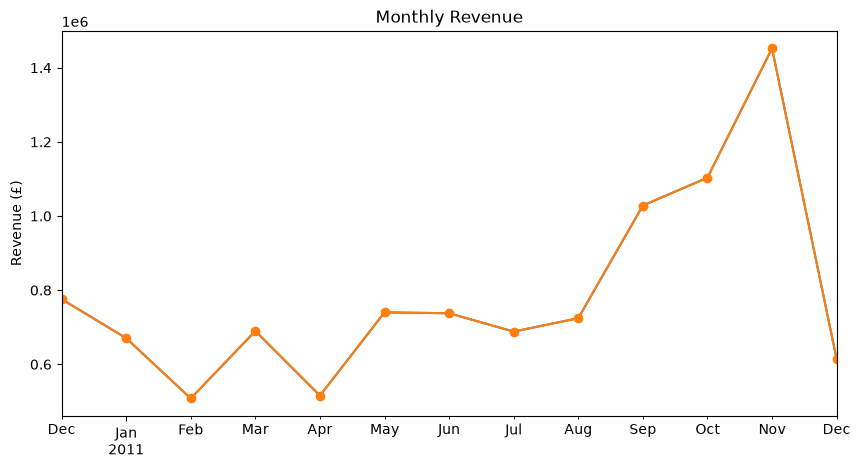

In [45]:
monthly = sales.set_index("InvoiceDate").resample("ME")["TotalPrice"].sum()
monthly.plot()
ax = monthly.plot(figsize=(10,5), marker="o", title="Monthly Revenue")
ax.set_ylabel("Revenue (£)")
ax.set_xlabel("")

Sales pick up a lot from September to November, makes sense for a gift shop before Christmas. December drops off hard but that's just because the data stops on Dec 9th, not a real slump.

### Which countries buy the most


In [46]:
country_rev = sales.groupby("Country")["TotalPrice"].sum().sort_values(ascending=False)
country_rev.head(10)

Country
United Kingdom    8725129.48
Netherlands        283889.34
EIRE               270850.86
Germany            205381.15
France             184493.00
Australia          138103.81
Spain               55706.56
Switzerland         53065.60
Japan               37416.37
Belgium             36927.34
Name: TotalPrice, dtype: float64

<Axes: ylabel='Country'>

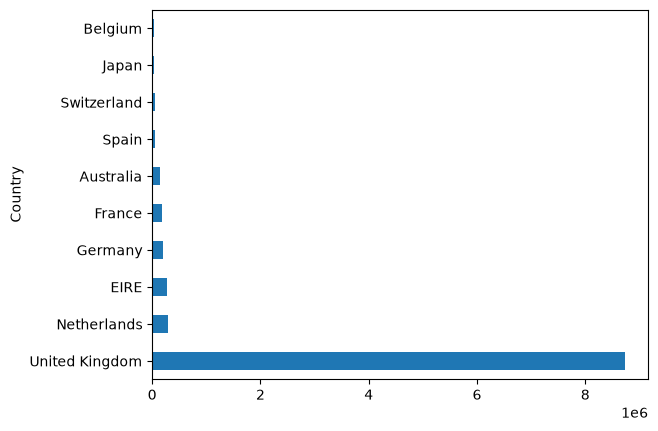

In [47]:
country_rev.head(10).plot(kind="barh")

In [48]:
uk_share = country_rev.loc["United Kingdom"] / country_rev.sum()
print(uk_share)

0.851406152703133


<Axes: ylabel='Country'>

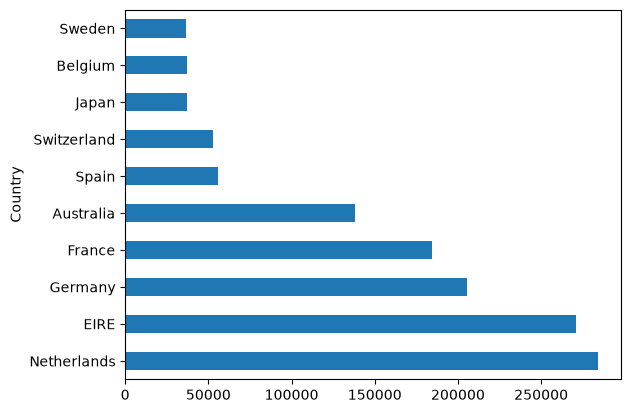

In [49]:
country_rev.drop("United Kingdom").head(10).plot(kind="barh")

In [50]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,is_cancelled,is_admin_code,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,False,False,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,False,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,False,False,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,False,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,False,20.34


UK is basically the whole business, around 85% of revenue. Netherlands, Ireland, Germany and France are the next biggest but nowhere close. If this business wanted to grow internationally I'd look at each of those markets on its own rather than lumping them together.

### Best selling products


<Axes: ylabel='Description'>

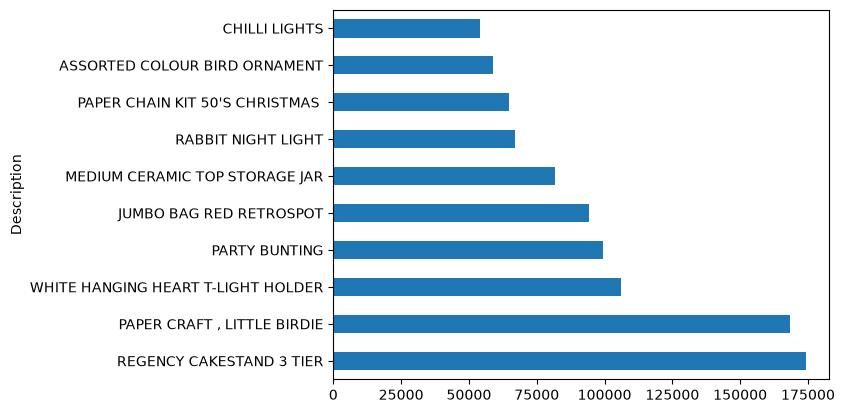

In [51]:
top_by_revenue = sales.groupby("Description")['TotalPrice'].sum().sort_values(ascending=False).head(10)
top_by_quantity = sales.groupby("Description")["Quantity"].sum().sort_values(ascending=False).head(10)

top_by_revenue.plot(kind="barh")

<Axes: ylabel='Description'>

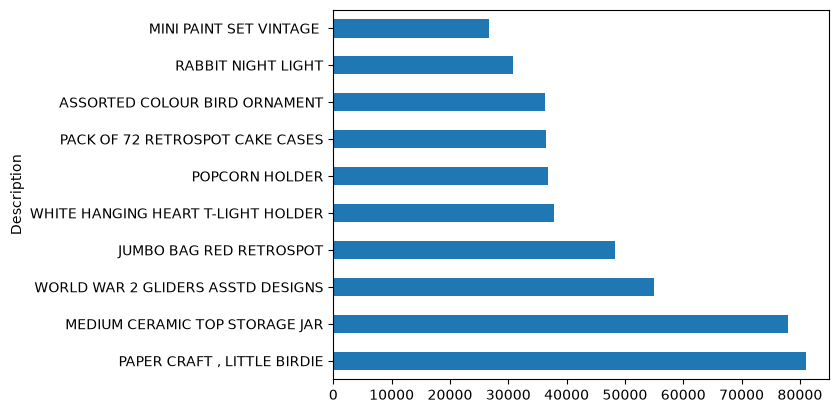

In [52]:
top_by_quantity.plot(kind="barh")

Interesting that the top products by revenue aren't the same as the top products by quantity. Some items sell a lot of units cheap, others sell fewer units but at a higher price. Worth keeping that distinction in mind rather than just looking at one list.

### When people actually order


In [53]:
sales["Hour"] = sales["InvoiceDate"].dt.hour
sales["DayOfWeek"] = sales["InvoiceDate"].dt.day_name()

In [54]:
sales.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,is_cancelled,is_admin_code,TotalPrice,Hour,DayOfWeek
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,False,False,15.30,8,Wednesday
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,False,20.34,8,Wednesday
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,False,False,22.00,8,Wednesday
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,False,20.34,8,Wednesday
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,False,20.34,8,Wednesday


In [55]:
sales.dtypes

InvoiceNo                   str
StockCode                   str
Description                 str
Quantity                  int64
InvoiceDate      datetime64[us]
UnitPrice               float64
CustomerID                Int64
Country                     str
is_cancelled               bool
is_admin_code              bool
TotalPrice              float64
Hour                      int32
DayOfWeek                   str
dtype: object

In [56]:
pivot = sales.pivot_table(
    index= "DayOfWeek",
    columns= "Hour",
    values= "TotalPrice",
    aggfunc="sum"
)
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
pivot = pivot.reindex(day_order)

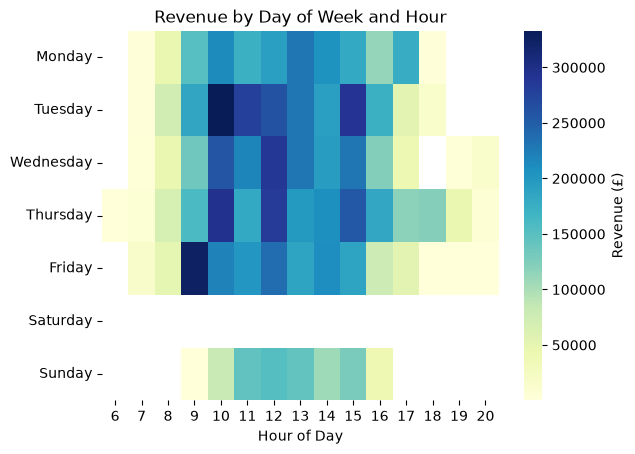

In [57]:
import seaborn as sns
ax = sns.heatmap(pivot, cmap="YlGnBu", cbar_kws={"label": "Revenue (£)"})
ax.set_title("Revenue by Day of Week and Hour")
ax.set_xlabel("Hour of Day")
ax.set_ylabel("")
plt.show()

Most orders happen on weekdays, roughly 9am to 4pm. And there's literally zero orders on Saturday, which is odd enough that I'd want to ask the business if that's on purpose or if it's a gap in the data.

## 5. Segmenting customers (RFM + K-Means)

This is the part I wanted to focus on most. Only using orders that have a CustomerID attached, since I can't segment a customer I can't identify.


In [58]:
snapshot_date = sales["InvoiceDate"].max() + pd.Timedelta(days=1)
print(snapshot_date)

2011-12-10 12:50:00


In [59]:
rfm = sales.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda x: (snapshot_date - x.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("TotalPrice", "sum")
).reset_index()

In [60]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1437.24
3,12349,19,1,1457.55
4,12350,310,1,294.40


In [61]:
rfm.describe()

,CustomerID,Recency,Frequency,Monetary
count,4334.0,4334.000000,4334.000000,4334.000000
mean,15299.251731,92.703046,4.245962,2015.973152
std,1721.994109,100.177047,7.634989,8903.673825
min,12346.0,1.000000,1.000000,3.750000
25%,13812.25,18.000000,1.000000,304.240000
50%,15297.5,51.000000,2.000000,662.565000
75%,16778.75,143.000000,5.000000,1631.622500
max,18287.0,374.000000,206.000000,279138.020000


Monetary is super skewed, most people spend a few hundred pounds but there's one customer who spent almost £280k. If I feed that straight into K-Means it'll basically just cluster by "big spender vs everyone else" and ignore Recency/Frequency. So log-transforming it first to squash that down.


In [62]:
import numpy as np
rfm["Frequency_log"] = np.log1p(rfm["Frequency"])
rfm["Monetary_log"] = np.log1p(rfm["Monetary"])

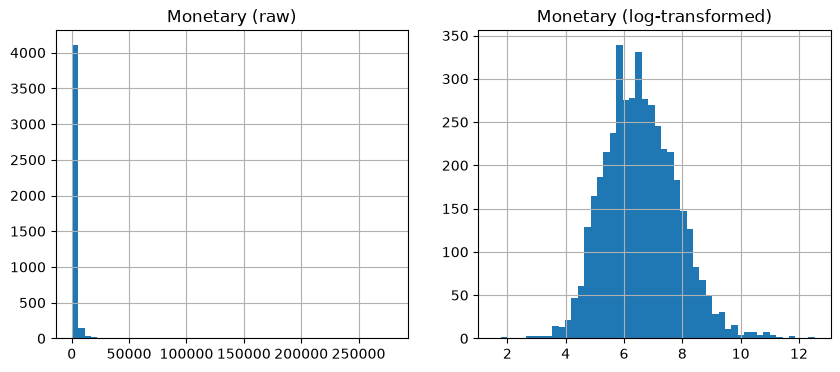

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(10,4))
rfm["Monetary"].hist(bins=50, ax=axes[0])
axes[0].set_title("Monetary (raw)")
rfm["Monetary_log"].hist(bins=50, ax=axes[1])
axes[1].set_title("Monetary (log-transformed)")
plt.show()

That log transform actually worked, went from a spike near zero to something that looks roughly normal.

Also scaling everything with StandardScaler, since Recency, Frequency and Monetary are all on totally different scales and I don't want one of them dominating just because the numbers are bigger.


In [64]:
from sklearn.preprocessing import StandardScaler

X = rfm[["Recency", "Frequency_log", "Monetary_log"]]
X_scaled = StandardScaler().fit_transform(X)

In [65]:
X_scaled.mean(axis=0)   
   

array([-5.69712969e-17,  2.95103121e-17,  4.85280687e-16])

In [66]:
X_scaled.std(axis=0) 

array([1., 1., 1.])

Mean is basically 0 and std is 1 for all three, so the scaling worked.

Now picking k using the elbow method. The drop in error is steep up to k=4, then it flattens out a lot after that. Going with k=4, also just feels like a more usable number of groups for a business to actually act on than like 7 or 8.


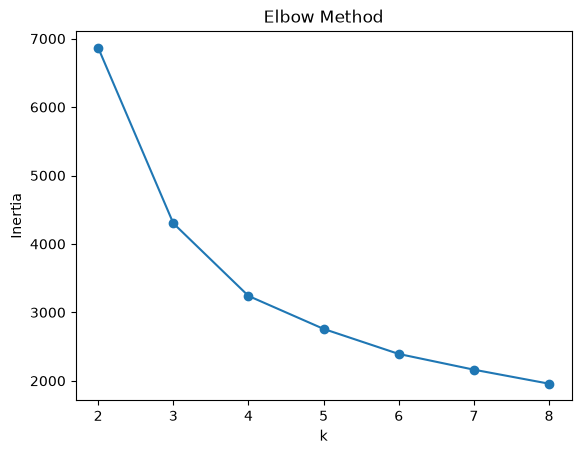

In [67]:
import os
os.environ["LOKY_MAX_CPU_COUNT"] = "4"

from sklearn.cluster import KMeans

inertias = []
k_range = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.plot(list(k_range), inertias, marker="o")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [68]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm["Segment"] = kmeans.fit_predict(X_scaled)
rfm["Segment"].value_counts()

Segment
0    1443
3    1387
1     938
2     566
Name: count, dtype: int64

Cluster sizes look reasonable, nothing tiny or dominating everything. Next step is figuring out what each cluster actually represents.


In [69]:
profile = rfm.groupby("Segment").agg(
    Customers=("CustomerID", "count"),
    Avg_Recency=("Recency", "mean"),
    Avg_Frequency=("Frequency", "mean"),
    Avg_Monetary=("Monetary", "mean")
).round(1)

profile

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary
Segment,,,,
0,1443,45.5,4.2,1622.2
1,938,259.9,1.4,387.1
2,566,19.5,15.8,9719.4
3,1387,58.6,1.5,383.6


In [70]:
revenue_share = rfm.groupby("Segment")["Monetary"].sum()
revenue_share_pct = (revenue_share / revenue_share.sum() * 100).round(1)
print(revenue_share)
print(revenue_share_pct)

Segment
0    2340827.63
1     363135.22
2    5501178.80
3     532085.99
Name: Monetary, dtype: float64
Segment
0    26.8
1     4.2
2    63.0
3     6.1
Name: Monetary, dtype: float64


This is the number I liked most from the whole project: one small cluster is generating way more revenue than its size would suggest, basically the classic 80/20 thing. Meanwhile two of the other clusters together are more than half the customers but barely register in revenue.

Naming the clusters based on what their Recency/Frequency/Monetary numbers actually look like (Champions, Loyal, At Risk, New/Occasional). Had to do this by hand since K-Means just numbers the clusters 0-3 with no meaning attached.


<Axes: title={'center': 'Customers per Segment'}, ylabel='SegmentName'>

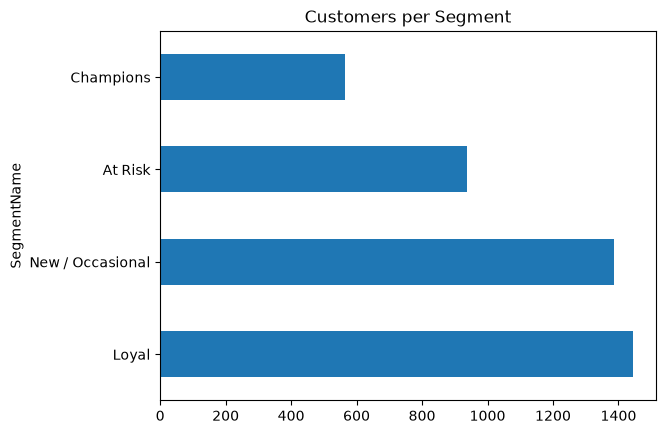

In [71]:
segment_names = {
    2: "Champions",
    0: "Loyal",
    3: "New / Occasional",
    1: "At Risk"
}
rfm["SegmentName"] = rfm["Segment"].map(segment_names)

rfm["SegmentName"].value_counts().plot(kind="barh", title="Customers per Segment")

<Axes: title={'center': 'Revenue by Segment'}, ylabel='SegmentName'>

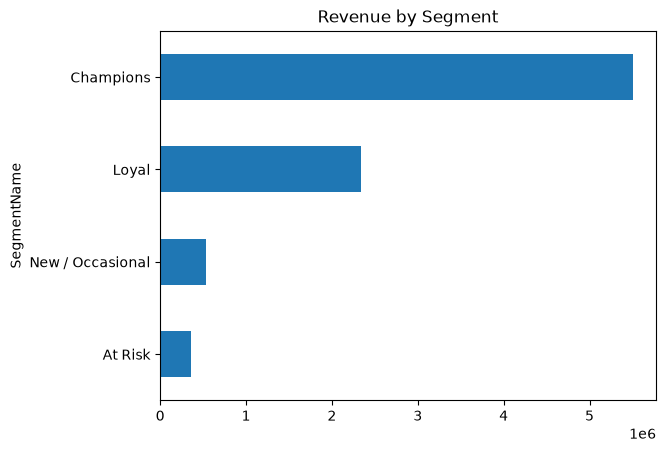

In [72]:
rfm.groupby("SegmentName")["Monetary"].sum().sort_values().plot(kind="barh", title="Revenue by Segment")

## 6. What I found

- Sales build up steadily before Christmas — monthly revenue climbs from around £700K in August to a peak of about £1.45M in November, then drops sharply in the last chart (that drop is just because the data stops on Dec 9, not a real sales crash).
- The business is almost entirely UK-based — the UK makes up 85.1% of total revenue. The next biggest markets are the Netherlands, EIRE (Ireland), Germany, and France, but each is tiny by comparison.
- The best-selling products by revenue aren't the same as the best-selling by quantity — for example, the Regency Cakestand 3 Tier is a top earner by revenue, but doesn't even appear in the top 10 by units sold. Cheaper items like the Mini Paint Set sell in much higher volume but bring in far less money per item.
- Orders happen on weekdays, during business hours — mostly between 9am and 4pm, Monday to Friday. There were zero orders on any Saturday in the entire dataset — worth flagging to the business as either a deliberate policy or a possible data gap.
- A small group of customers drives most of the revenue — the "Champions" segment is just 566 customers (about 13% of the customer base), but they generate 63% of total revenue. Meanwhile, the "At Risk" and "New/Occasional" segments together make up over half of all customers but only contribute about 10% of revenue combined.



## 7. Limitations

- About 25% of transactions have no CustomerID attached (135,080 out of 541,909 rows originally). These were kept in the revenue/product analysis, but excluded from the customer segmentation — meaning the RFM/Champions analysis only reflects the ~75% of orders that could be traced back to a specific person. These are likely guest checkouts or a data-linking issue on the retailer's side.
- The dataset only covers about 12 months (Dec 2010 to Dec 2011), and December is a partial month (only 9 days). This means there's no way to compare year-over-year, and the December revenue drop in the trend chart is a data artifact, not a real business decline.
- Country data is self-reported and inconsistent in places (e.g. entries like "EIRE" instead of "Ireland," or "European Community" as a catch-all) — treated as-is here, but would need standardizing for a more rigorous geographic breakdown.
-- The customer segments were named manually based on eyeballing the RFM averages, not through a formal validation step — a more rigorous version would test cluster stability or try alternative values of k beyond the elbow method.
